In [1]:
# Install library yang dibutuhakan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tabulate import tabulate
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set tampilan
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
plt.style.use('seaborn-v0_8-whitegrid')
print("✅ Semua library berhasil diimport!")


✅ Semua library berhasil diimport!


# LANGKAH 4: Analisis data (Mengidentifikasi Anomali)

In [163]:
# Identifikasi data anomali / miss

# Anomali merpakan 
# 1. "Salah terima = cluster menjunjukan tidak layak , tapi ground truth nya terima"
# 2. "Salah tolak = cluster menjunjkan layak, tapi ground truth nya tidak terima"

print("=" * 60)
print("KARAKTERISTIK CLUSTER (untuk tentukan mana yang Layak)")
print("=" * 60)
cluster_profile = df_clean.groupby('Cluster_KMeans').agg({
    'IPK': 'mean',
    'Penghasilan': lambda x: (x == 'Rendah').mean() * 100,  # % penghasilan rendah
    'Tanggungan': 'mean',
    'Ground_Truth': 'mean'  # % yang diterima ground truth
}).round(2)
print(cluster_profile)

# Interpretasi
print("\n INTERPRETASI:")
print("   Cluster dengan IPK tinggi, penghasilan rendah, tanggungan banyak = LAYAK")
print("   Cluster dengan IPK rendah, penghasilan tinggi, tanggungan sedikit = TIDAK LAYAK")

# Buat label layak/tidak layak berdasarkan cluster
cluster_0_means = df_fitur[df_fitur['Cluster_KMeans'] == 0][fitur_kolom].mean()
cluster_1_means = df_fitur[df_fitur['Cluster_KMeans'] == 1][fitur_kolom].mean()

# Asumsikan cluster dengan skor ekonomi lebih rendah = "Tidak Layak" (Layak dapat beasiswa)
# Bandingkan berdasarkan IPK (lebih tinggi = baik) dan Penghasilan (lebih rendah = layak)
if cluster_0_means['IPK'] > cluster_1_means['IPK']:
    # Cluster 0 = Layak (IPK tinggi)
    layak_cluster = 0
    tidak_layak_cluster = 1
else:
    # Cluster 1 = Layak (IPK tinggi)
    layak_cluster = 1
    tidak_layak_cluster = 0

print(f"\n Cluster {layak_cluster} = LAYAK (memenuhi kriteria ekonomi kurang)")
print(f"Cluster {tidak_layak_cluster} = TIDAK LAYAK (tidak memenuhi kriteria)")

# Bikin kolom label yang lebih gampang dibaca
df_clean['Ground_Truth_Label'] = df_clean['Ground_Truth'].map({1: 'Terima', 0: 'Tidak Terima'})
df_clean['Cluster_KMeans_Label'] = df_clean['Cluster_KMeans'].map({layak_cluster: 'Layak', tidak_layak_cluster: 'Tidak Layak'})

# Filter anomali
# Anomali Type 1: Ground Truth TERIMA tapi Cluster TIDAK LAYAK (Salah Terima)
df_salah_terima = df_clean[
    (df_clean['Ground_Truth'] == 1) & 
    (df_clean['Cluster_KMeans'] == tidak_layak_cluster)
].copy()

# Anomali Type 2: Ground Truth TIDAK TERIMA tapi Cluster LAYAK (Salah Tolak)
df_salah_tolak = df_clean[
    (df_clean['Ground_Truth'] == 0) & 
    (df_clean['Cluster_KMeans'] == layak_cluster)
].copy()

# Gabung semua anomali
df_anomali = pd.concat([df_salah_terima, df_salah_tolak], ignore_index=True)
df_anomali['Tipe_Anomali'] = ['Salah Terima'] * len(df_salah_terima) + ['Salah Tolak'] * len(df_salah_tolak)

print("\n" + "=" * 60)
print("HASIL IDENTIFIKASI ANOMALI")
print("=" * 60)
print(f"\nTotal Anomali: {len(df_anomali)} data")
print(f"   • Salah Terima (diterima tapi seharusnya tidak): {len(df_salah_terima)} orang")
print(f"   • Salah Tolak (ditolak tapi seharusnya diterima): {len(df_salah_tolak)} orang")

if 'No' in df_anomali.columns:
    df_anomali = df_anomali.drop(columns=['No'])



KARAKTERISTIK CLUSTER (untuk tentukan mana yang Layak)
                 IPK  Penghasilan  Tanggungan  Ground_Truth
Cluster_KMeans                                             
0               3.32        33.25        3.16          0.48
1               3.31        20.48        2.20          0.11

 INTERPRETASI:
   Cluster dengan IPK tinggi, penghasilan rendah, tanggungan banyak = LAYAK
   Cluster dengan IPK rendah, penghasilan tinggi, tanggungan sedikit = TIDAK LAYAK

 Cluster 0 = LAYAK (memenuhi kriteria ekonomi kurang)
Cluster 1 = TIDAK LAYAK (tidak memenuhi kriteria)

HASIL IDENTIFIKASI ANOMALI

Total Anomali: 286 data
   • Salah Terima (diterima tapi seharusnya tidak): 70 orang
   • Salah Tolak (ditolak tapi seharusnya diterima): 216 orang


In [170]:
# Kita harus menyimpan data yang anomali

kolom_tampilkan = ['Nama Lengkap', 'IPK', 'Penghasilan', 
                   'Pekerjaan Orang Tua', 'Tanggungan', 
                   'Ikut Organisasi', 'Ikut UKM',
                   'Ground_Truth', 'Cluster_KMeans', 'Tipe_Anomali']

df_anomali_display = df_anomali.copy()

# df_anomali_display.columns = ['Nama', 'IPK', 'Penghasilan', 
#                                'Pekerjaan Ortu', 'Tanggungan',
#                                'Ikut Organisasi', 'Ikut UKM',
#                                'Status Aktual', 'Hasil Cluster', 'Tipe Anomali']

df_anomali_display = df_anomali_display.reset_index(drop=True)
df_anomali_display.insert(0, 'No', range(1, len(df_anomali_display) + 1))

print("=" * 70)
print("DATA ANOMALI (yang meleset dari kriteria)")
print("=" * 70)
print(f"Total anomali: {len(df_anomali_display)} orang")

# print(tabulate(df))

print(tabulate(df_anomali.head(286), headers='keys', tablefmt='psql', showindex=False))

DATA ANOMALI (yang meleset dari kriteria)
Total anomali: 286 orang
+-------------------------+--------------------------------------------------+-----------------+--------------------------------------+-----------------------------+---------------+-------+-------------------+------------+-------+--------------------------------------+---------------+--------------+-------------------+----------------+----------------------+------------------+------------------------+----------------+
| Nama Lengkap            | Prodi                                            | Jenis Kelamin   | Jarak Tempat Tinggal kekampus (Km)   | Asal Sekolah                |   Tahun Lulus |   SKS | Ikut Organisasi   | Ikut UKM   |   IPK | Pekerjaan Orang Tua                  | Penghasilan   |   Tanggungan | Status Beasiswa   |   Ground_Truth | Ground_Truth_Label   |   Cluster_KMeans | Cluster_KMeans_Label   | Tipe_Anomali   |
|-------------------------+--------------------------------------------------+-----------

# LANGKAH 5: Visualisasi distribusi anomali

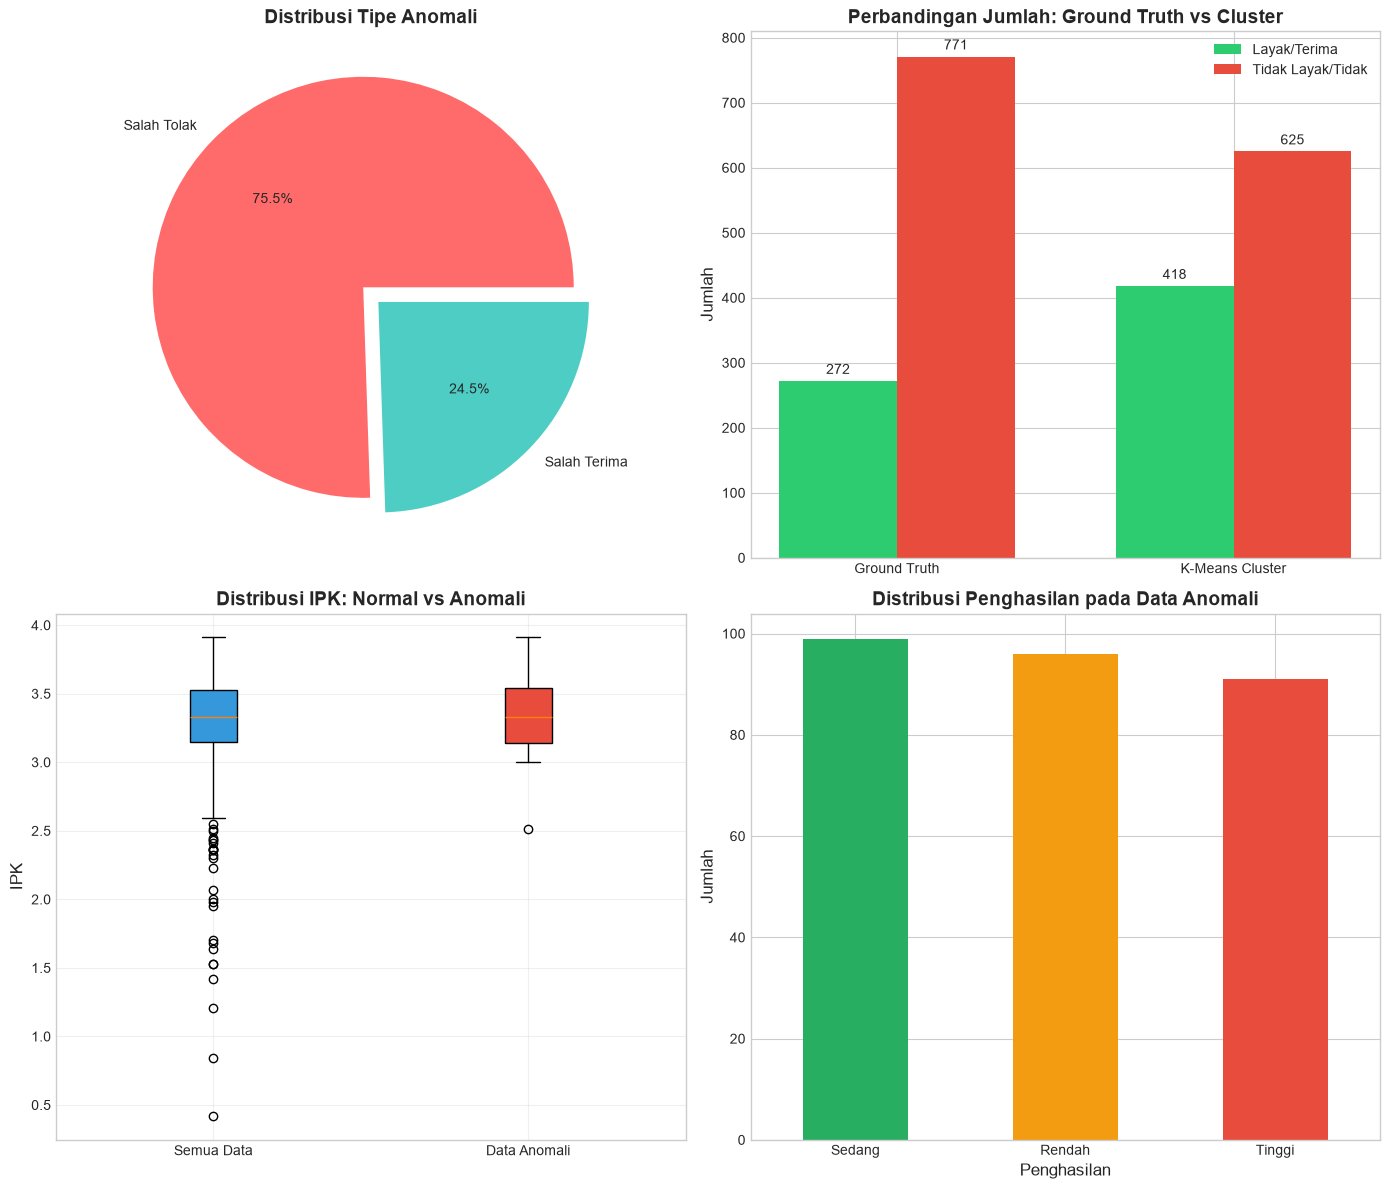

In [173]:
# Visualisasi distribusi anomali

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Pie Chart Tipe Anomali
ax1 = axes[0, 0]
if len(df_anomali) > 0:
    anomali_counts = df_anomali['Tipe_Anomali'].value_counts()
    colors = ['#ff6b6b', '#4ecdc4']
    wedges, texts, autotexts = ax1.pie(anomali_counts.values, labels=anomali_counts.index, 
                                        autopct='%1.1f%%', colors=colors, explode=[0.05, 0.05])
    ax1.set_title('Distribusi Tipe Anomali', fontsize=14, fontweight='bold')
else:
    ax1.text(0.5, 0.5, 'Tidak ada anomali', ha='center', va='center', fontsize=12)

# 2. Bar Chart Ground Truth vs Cluster
ax2 = axes[0, 1]
categories = ['Ground Truth', 'K-Means Cluster']
terima_data = [df_clean['Ground_Truth'].sum(), (df_clean['Cluster_KMeans'] == layak_cluster).sum()]
tidak_terima_data = [(df_clean['Ground_Truth']==0).sum(), (df_clean['Cluster_KMeans'] == tidak_layak_cluster).sum()]

x = np.arange(len(categories))
width = 0.35

bars1 = ax2.bar(x - width/2, terima_data, width, label='Layak/Terima', color='#2ecc71')
bars2 = ax2.bar(x + width/2, tidak_terima_data, width, label='Tidak Layak/Tidak', color='#e74c3c')

ax2.set_ylabel('Jumlah', fontsize=12)
ax2.set_title('Perbandingan Jumlah: Ground Truth vs Cluster', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(categories)
ax2.legend()

# Tambahkan label di atas bar
for bar in bars1:
    height = bar.get_height()
    ax2.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')
for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{int(height)}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom')

# 3. Boxplot IPK berdasarkan Anomali
ax3 = axes[1, 0]
if len(df_anomali) > 0:
    # Bandingkan IPK
    ipk_normal = df_clean[df_clean['Nama Lengkap'].isin(df_anomali['Nama Lengkap'])]['IPK']
    ipk_anomali = df_anomali['IPK']
    
    data_boxplot = [df_clean['IPK'], ipk_anomali if len(ipk_anomali) > 0 else [0]]
    bp = ax3.boxplot(data_boxplot, tick_labels=['Semua Data', 'Data Anomali'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#3498db')
    bp['boxes'][1].set_facecolor('#e74c3c')
    ax3.set_ylabel('IPK', fontsize=12)
    ax3.set_title('Distribusi IPK: Normal vs Anomali', fontsize=14, fontweight='bold')
else:
    ax3.text(0.5, 0.5, 'Tidak ada anomali', ha='center', va='center', fontsize=12)
ax3.grid(True, alpha=0.3)

# 4. Distribusi Penghasilan pada Anomali
ax4 = axes[1, 1]
if len(df_anomali) > 0:
    penghasilan_counts = df_anomali['Penghasilan'].value_counts()
    colors_bar = ['#27ae60', '#f39c12', '#e74c3c']
    penghasilan_counts.plot(kind='bar', ax=ax4, color=colors_bar[:len(penghasilan_counts)])
    ax4.set_xlabel('Penghasilan', fontsize=12)
    ax4.set_ylabel('Jumlah', fontsize=12)
    ax4.set_title('Distribusi Penghasilan pada Data Anomali', fontsize=14, fontweight='bold')
    ax4.set_xticklabels(ax4.get_xticklabels(), rotation=0)
else:
    ax4.text(0.5, 0.5, 'Tidak ada anomali', ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.savefig('visualisasi_anomali.png', dpi=300, bbox_inches='tight')
plt.show()

In [174]:
# Analisis detail anomali per kolom

print("=" * 60)
print("STATISTIK DESKRIPTIF DATA ANOMALI")
print("=" * 60)

# Pisahkan anomali berdasarkan tipe
print("\n ANOMALI 'SALAH TERIMA' (Diterima tapi seharusnya tidak):")
print("-" * 60)
if len(df_salah_terima) > 0:
    print(f"Jumlah: {len(df_salah_terima)} orang")
    print(f"\nRata-rata IPK: {df_salah_terima['IPK'].mean():.2f}")
    print(f"Distribusi Penghasilan:")
    print(df_salah_terima['Penghasilan'].value_counts())
    print(f"\nDistribusi Pekerjaan Orang Tua:")
    print(df_salah_terima['Pekerjaan Orang Tua'].value_counts())
    print(f"\nRata-rata Tanggungan: {df_salah_terima['Tanggungan'].mean():.1f}")
else:
    print("Tidak ada data 'Salah Terima'")

print("\n\n ANOMALI 'SALAH TOLAK' (Ditolak tapi seharusnya diterima):")
print("-" * 60)
if len(df_salah_tolak) > 0:
    print(f"Jumlah: {len(df_salah_tolak)} orang")
    print(f"\nRata-rata IPK: {df_salah_tolak['IPK'].mean():.2f}")
    print(f"Distribusi Penghasilan:")
    print(df_salah_tolak['Penghasilan'].value_counts())
    print(f"\nDistribusi Pekerjaan Orang Tua:")
    print(df_salah_tolak['Pekerjaan Orang Tua'].value_counts())
    print(f"\nRata-rata Tanggungan: {df_salah_tolak['Tanggungan'].mean():.1f}")
else:
    print("Tidak ada data 'Salah Tolak'")

STATISTIK DESKRIPTIF DATA ANOMALI

 ANOMALI 'SALAH TERIMA' (Diterima tapi seharusnya tidak):
------------------------------------------------------------
Jumlah: 70 orang

Rata-rata IPK: 3.51
Distribusi Penghasilan:
Penghasilan
Sedang    26
Rendah    25
Tinggi    19
Name: count, dtype: int64

Distribusi Pekerjaan Orang Tua:
Pekerjaan Orang Tua
Petani                         16
Wiraswasta                     10
Sudah Meninggal                 3
Buruh                           2
Technical Writer                2
Senior Editor                   2
Recruiting Manager              2
Tax Accountant                  2
Karyawan Swasta                 1
PNS                             1
Pedagang                        1
Nurse Practicioner              1
Assistant Media Planner         1
VP Quality Control              1
Geologist III                   1
Social Worker                   1
Physical Therapy Assistant      1
Media Manager III               1
Staff Accountant II             1
Research

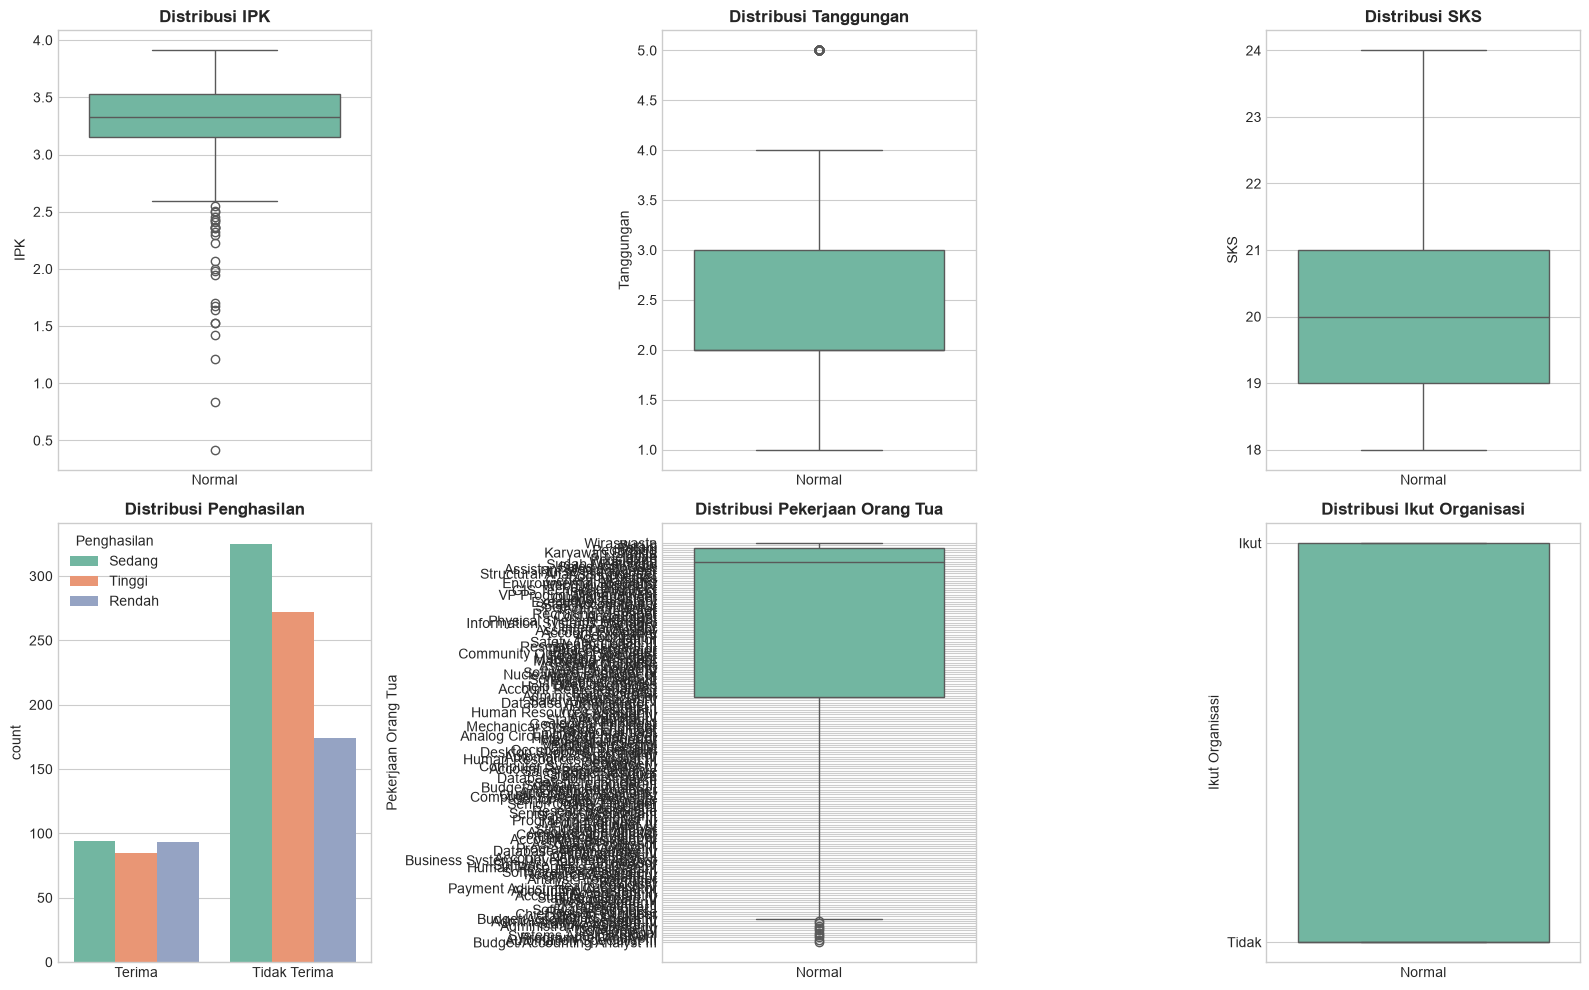

In [175]:
# Bloxpot perbandingan per fitur

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

fitur_visual = ['IPK', 'Tanggungan', 'SKS', 'Penghasilan', 'Pekerjaan Orang Tua', 'Ikut Organisasi']

# Encode untuk visualisasi
df_vis = df_clean.copy()
if 'Penghasilan' in df_vis.columns:
    encode_order = {'Rendah': 0, 'Sedang': 1, 'Tinggi': 2}
    df_vis['Penghasilan_encoded'] = df_vis['Penghasilan'].map(encode_order)

for idx, fitur in enumerate(fitur_visual[:6]):
    ax = axes[idx // 3, idx % 3]
    
    if fitur == 'Penghasilan':
        # Buat grouped data
        data_groups = [
            df_vis[df_vis['Ground_Truth'] == 0]['Penghasilan'],
            df_vis[df_vis['Ground_Truth'] == 1]['Penghasilan'],
            df_vis[df_vis['Tipe_Anomali'] == 'Salah Terima']['Penghasilan'] if 'Tipe_Anomali' in df_vis.columns and 'Salah Terima' in df_vis['Tipe_Anomali'].values else pd.Series([]),
            df_vis[df_vis['Tipe_Anomali'] == 'Salah Tolak']['Penghasilan'] if 'Tipe_Anomali' in df_vis.columns and 'Salah Tolak' in df_vis['Tipe_Anomali'].values else pd.Series([])
        ]
        labels = ['Tidak Terima', 'Terima', 'Salah Terima', 'Salah Tolak']
        colors = ['#e74c3c', '#2ecc71', '#f39c12', '#9b59b6']
        
        # Count plot untuk kategorik
        df_melt = df_vis[['Ground_Truth', 'Penghasilan']].copy()
        df_melt['Kategori'] = df_melt['Ground_Truth'].map({0: 'Tidak Terima', 1: 'Terima'})
        sns.countplot(data=df_melt, x='Kategori', hue='Penghasilan', ax=ax, palette='Set2')
        ax.set_title(f'Distribusi {fitur}', fontsize=12, fontweight='bold')
        ax.set_xlabel('')
        ax.legend(title=fitur)
    else:
        # Boxplot untuk numerik
        df_vis['Kategori'] = 'Normal'
        if 'Tipe_Anomali' in df_vis.columns:
            df_vis.loc[df_vis['Tipe_Anomali'] == 'Salah Terima', 'Kategori'] = 'Salah Terima'
            df_vis.loc[df_vis['Tipe_Anomali'] == 'Salah Tolak', 'Kategori'] = 'Salah Tolak'
        
        sns.boxplot(data=df_vis, x='Kategori', y=fitur, ax=ax, palette='Set2')
        ax.set_title(f'Distribusi {fitur}', fontsize=12, fontweight='bold')
        ax.set_xlabel('')

plt.tight_layout()
plt.savefig('boxplot_perbandingan.png', dpi=300, bbox_inches='tight')
plt.show()

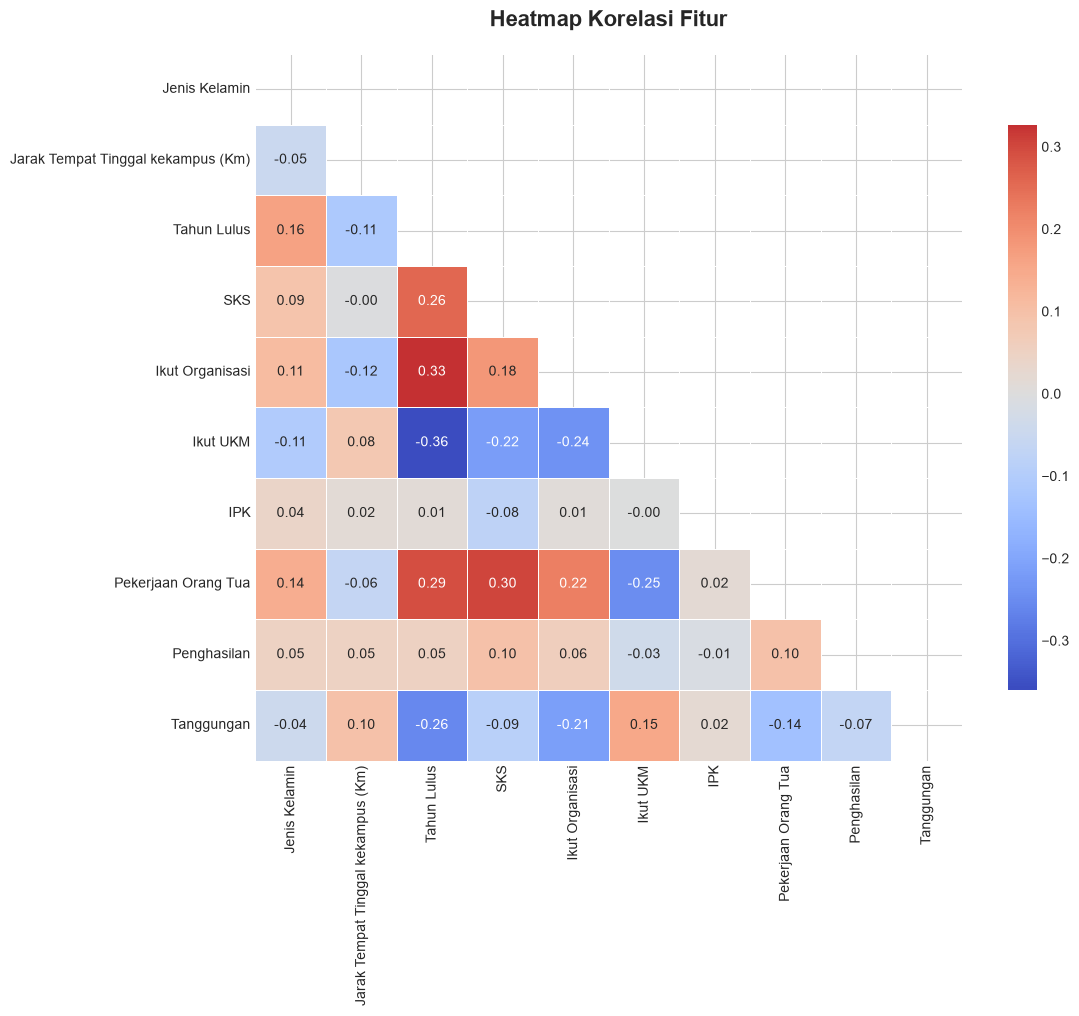

In [179]:
# Heatmap korelasi

df_numeric = df[fitur_kolom].copy()

# Encode kategorik (semua kolom yang bukan numerik)
for col in df_numeric.columns:
    if not pd.api.types.is_numeric_dtype(df_numeric[col]):
        le = LabelEncoder()
        df_numeric[col] = le.fit_transform(df_numeric[col].astype(str))

# Hitung korelasi
corr_matrix = df_numeric.corr()

# Plot heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Heatmap Korelasi Fitur', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('heatmap_korelasi.png', dpi=300, bbox_inches='tight')
plt.show()

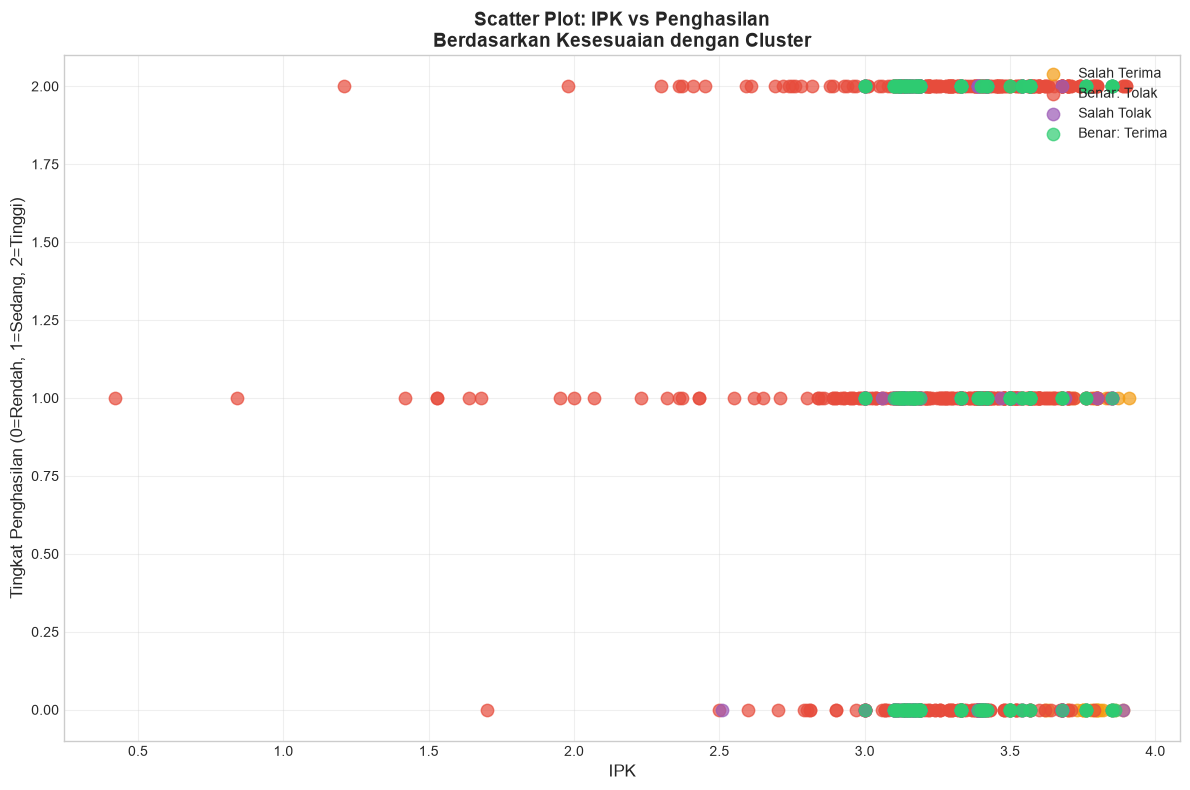


📊 Ringkasan Kategori:
Kategori
Benar: Tolak     555
Salah Tolak      216
Benar: Terima    202
Salah Terima      70
Name: count, dtype: int64


In [180]:
# Scater plot IPK vS Penghasilan

# Encode penghasilan
df_scatter = df_clean.copy()
penghasilan_map = {'Rendah': 0, 'Sedang': 1, 'Tinggi': 2}
df_scatter['Penghasilan_num'] = df_scatter['Penghasilan'].map(penghasilan_map)

# Tambah kolom kategori
def get_kategori(row):
    if row['Ground_Truth'] == 1 and row['Cluster_KMeans'] == layak_cluster:
        return 'Benar: Terima'
    elif row['Ground_Truth'] == 0 and row['Cluster_KMeans'] == tidak_layak_cluster:
        return 'Benar: Tolak'
    elif row['Ground_Truth'] == 1 and row['Cluster_KMeans'] == tidak_layak_cluster:
        return 'Salah Terima'
    else:
        return 'Salah Tolak'

df_scatter['Kategori'] = df_scatter.apply(get_kategori, axis=1)

# Scatter plot
plt.figure(figsize=(12, 8))
colors = {'Benar: Terima': '#2ecc71', 'Benar: Tolak': '#e74c3c', 
          'Salah Terima': '#f39c12', 'Salah Tolak': '#9b59b6'}

for kategori in df_scatter['Kategori'].unique():
    subset = df_scatter[df_scatter['Kategori'] == kategori]
    plt.scatter(subset['IPK'], subset['Penghasilan_num'], 
                label=kategori, alpha=0.7, s=80, c=colors.get(kategori, 'gray'))

plt.xlabel('IPK', fontsize=12)
plt.ylabel('Tingkat Penghasilan (0=Rendah, 1=Sedang, 2=Tinggi)', fontsize=12)
plt.title('Scatter Plot: IPK vs Penghasilan\nBerdasarkan Kesesuaian dengan Cluster', 
          fontsize=14, fontweight='bold')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('scatter_ipk_penghasilan.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n📊 Ringkasan Kategori:")
print(df_scatter['Kategori'].value_counts())

# LANGKAH 6 : KESIMPULAN

In [182]:
# Kesimpulan

print("=" * 70)
print("RINGKASAN ANALISIS ANOMALI BEASISWA")
print("=" * 70)

print("\n DATASET:")
print(f"   • Total data: {len(df_clean)} pendaftar")
print(f"   • Ground Truth - Terima: {df_clean['Ground_Truth'].sum()}")
print(f"   • Ground Truth - Tidak: {(df_clean['Ground_Truth']==0).sum()}")

print("\n HASIL CLUSTERING (K-Means k=2):")
print(f"   • Cluster Layak: {(df_clean['Cluster_KMeans']==layak_cluster).sum()}")
print(f"   • Cluster Tidak Layak: {(df_clean['Cluster_KMeans']==tidak_layak_cluster).sum()}")
print(f"   • Silhouette Score: {silhouette_kmeans:.4f}")
print(f"   • Davies-Bouldin Index: {db_kmeans:.4f}")

print("\n ANOMALI YANG DITEMUKAN:")
print(f"   • Total Anomali: {len(df_anomali)} ({len(df_anomali)/len(df_clean)*100:.1f}%)")
print(f"   • Salah Terima: {len(df_salah_terima)} orang")
print(f"   • Salah Tolak: {len(df_salah_tolak)} orang")

print("\n KARAKTERISTIK ANOMALI 'SALAH TERIMA':")
if len(df_salah_terima) > 0:
    print(f"   • Rata-rata IPK: {df_salah_terima['IPK'].mean():.2f}")
    print(f"   • Penghasilan dominan: {df_salah_terima['Penghasilan'].mode().values[0]}")
    print(f"   • Rata-rata Tanggungan: {df_salah_terima['Tanggungan'].mean():.1f}")

print("\n KARAKTERISTIK ANOMALI 'SALAH TOLAK':")
if len(df_salah_tolak) > 0:
    print(f"   • Rata-rata IPK: {df_salah_tolak['IPK'].mean():.2f}")
    print(f"   • Penghasilan dominan: {df_salah_tolak['Penghasilan'].mode().values[0]}")
    print(f"   • Rata-rata Tanggungan: {df_salah_tolak['Tanggungan'].mean():.1f}")

print("\n" + "=" * 70)
print(" KESIMPULAN:")
print("=" * 70)
print("""
Berdasarkan hasil analisis menggunakan metode clustering (K-Means dan 
Agglomerative), ditemukan bahwa terdapat ketidaksesuaian antara keputusan 
pemberian beasiswa dengan karakteristik data pendaftar.

Temuan utama:
1. Ditemukan {} anomali ({:.1f}%) yang perlu dievaluasi
2. {} pendaftar yang seharusnya TIDAK LAYAK justru menerima beasiswa
3. {} pendaftar yang seharusnya LAYAK justru ditolak

Rekomendasi untuk pihak pemberi beasiswa:
1. Evaluasi ulang kriteria seleksi yang digunakan
2. Pertimbangkan faktor-faktor yang menyebabkan anomali
3. Lakukan audit berkala terhadap hasil seleksi
""".format(len(df_anomali), len(df_anomali)/len(df_clean)*100, 
           len(df_salah_terima), len(df_salah_tolak)))

print("=" * 70)
print("ANALISIS SELESAI")
print("=" * 70)

RINGKASAN ANALISIS ANOMALI BEASISWA

 DATASET:
   • Total data: 1043 pendaftar
   • Ground Truth - Terima: 272
   • Ground Truth - Tidak: 771

 HASIL CLUSTERING (K-Means k=2):
   • Cluster Layak: 418
   • Cluster Tidak Layak: 625
   • Silhouette Score: 0.1878
   • Davies-Bouldin Index: 2.1339

 ANOMALI YANG DITEMUKAN:
   • Total Anomali: 286 (27.4%)
   • Salah Terima: 70 orang
   • Salah Tolak: 216 orang

 KARAKTERISTIK ANOMALI 'SALAH TERIMA':
   • Rata-rata IPK: 3.51
   • Penghasilan dominan: Sedang
   • Rata-rata Tanggungan: 2.6

 KARAKTERISTIK ANOMALI 'SALAH TOLAK':
   • Rata-rata IPK: 3.30
   • Penghasilan dominan: Sedang
   • Rata-rata Tanggungan: 3.1

 KESIMPULAN:

Berdasarkan hasil analisis menggunakan metode clustering (K-Means dan 
Agglomerative), ditemukan bahwa terdapat ketidaksesuaian antara keputusan 
pemberian beasiswa dengan karakteristik data pendaftar.

Temuan utama:
1. Ditemukan 286 anomali (27.4%) yang perlu dievaluasi
2. 70 pendaftar yang seharusnya TIDAK LAYAK just

### Interpretasi Fitur dengan SHAP (Surrogate Model)

Untuk memenuhi ketentuan teknis penggunaan library interpretasi model wajib (**SHAP** atau **LIME**), bagian ini mengimplementasikan model *surrogate* (pengganti) berupa Random Forest yang menirukan hasil clustering K-Means. Setelah model surrogate dilatih, SHAP digunakan untuk menjelaskan kontribusi masing-masing fitur terhadap pengelompokan cluster.

⏳ Menghitung SHAP Feature Importance...


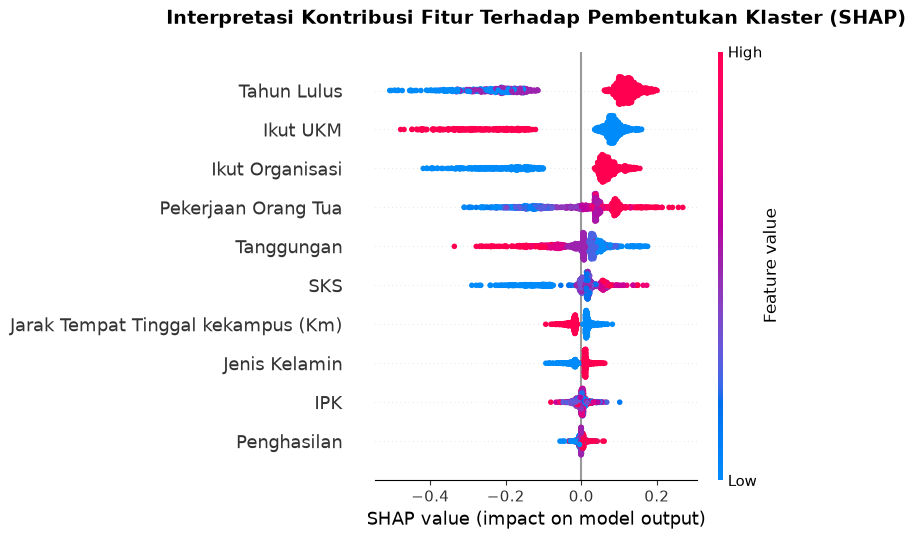

✅ Analisis SHAP selesai! Visualisasi disimpan ke: ../app/assets/shap_feature_importance.png


In [2]:
import pickle
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import os
import sys
from sklearn.ensemble import RandomForestClassifier

print("⏳ Menghitung SHAP Feature Importance...")

# 1. Sesuaikan path berdasarkan Working Directory (apakah dijalankan dari root atau folder notebooks)
is_notebooks_dir = not os.path.exists("models")
base_dir = "../" if is_notebooks_dir else ""

# Tambahkan root dir ke sys.path jika dijalankan dari subfolder notebooks agar bisa import src
if is_notebooks_dir:
    root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
    if root_dir not in sys.path:
        sys.path.append(root_dir)

prep_path = os.path.join(base_dir, 'models/preprocessing.pkl')
model_path = os.path.join(base_dir, 'models/best_model.pkl')
data_path = os.path.join(base_dir, 'data/raw/dataset.csv')
assets_dir = os.path.join(base_dir, 'app/assets')

# 2. Load Preprocessor dan Model Terbaik
try:
    with open(prep_path, 'rb') as f:
        prep_data = pickle.load(f)
    fitur_kolom = prep_data['fitur_kolom']
    scaler = prep_data['scaler']
    le_dict = prep_data['le_dict']

    with open(model_path, 'rb') as f:
        kmeans = pickle.load(f)
        
    # 3. Load and Preprocess Data
    from src.data_preprocessing import clean_data
    df_clean = clean_data(data_path)
    df_fitur = df_clean[fitur_kolom].copy()

    # Encode kategorik
    df_encoded = df_fitur.copy()
    for col in df_encoded.columns:
        if col in le_dict:
            le = le_dict[col]
            mapping = dict(zip(le.classes_, range(len(le.classes_))))
            df_encoded[col] = df_encoded[col].apply(lambda x: mapping.get(str(x), 0))

    # Scaling
    df_scaled = pd.DataFrame(
        scaler.transform(df_encoded),
        columns=df_encoded.columns,
        index=df_encoded.index
    )

    # Predict cluster labels
    cluster_labels = kmeans.predict(df_scaled)

    # 4. Latih model Surrogate (Random Forest)
    # Model ini akan menirukan keputusan clustering K-Means secara supervised
    surrogate_model = RandomForestClassifier(random_state=42, n_estimators=100)
    surrogate_model.fit(df_scaled, cluster_labels)

    # 5. Hitung SHAP Values
    explainer = shap.TreeExplainer(surrogate_model)
    shap_values = explainer.shap_values(df_scaled)

    # 6. Visualisasi SHAP Summary Plot
    plt.figure(figsize=(10, 6))
    
    # Menentukan class/cluster mana yang dijelaskan
    # Jika shap_values adalah list (multiclass/binary versi lama), ambil indeks 1 (untuk cluster 1)
    if isinstance(shap_values, list):
        shap.summary_plot(shap_values[1], df_scaled, show=False)
    elif len(shap_values.shape) == 3: # format baru multiclass
        shap.summary_plot(shap_values[:, :, 1], df_scaled, show=False)
    else:
        shap.summary_plot(shap_values, df_scaled, show=False)

    plt.title('Interpretasi Kontribusi Fitur Terhadap Pembentukan Klaster (SHAP)', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    
    # Simpan hasil visualisasi
    os.makedirs(assets_dir, exist_ok=True)
    save_path = os.path.join(assets_dir, 'shap_feature_importance.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ Analisis SHAP selesai! Visualisasi disimpan ke: {save_path}")
except Exception as e:
    print(f"❌ Terjadi kesalahan saat menghitung SHAP: {e}")
    print("Pastikan package 'shap' sudah terinstall (pip install shap).")